# Categorical Target Encoding — Plant Health Status Prediction

**Preprocessing technique:** Categorical Target Encoding
**Assigned to:** Member 2 (IT0002)

## 1. Introduction

**What is target encoding?**
Target encoding (also called mean encoding) is a technique for converting a categorical
variable into a numeric one by replacing each category with a statistic computed from the
target variable for that category — most commonly the mean of the target for all rows sharing
that category. Instead of creating a separate binary column for every category (as one-hot
encoding does), target encoding condenses the category's relationship with the target into a
small number of informative numeric columns.

**Why is it useful here?**
In this dataset, `Plant_ID` is a categorical column with 10 unique plants (1–10). Although it is
stored as an integer, it does not represent a measurable quantity — it identifies *which plant*
a sensor reading came from, not an amount of anything. Different plants may have consistently
different health outcomes (e.g. due to genetics, placement, or care history), so `Plant_ID`
likely carries real predictive signal. One-hot encoding it would work but would add 10 sparse
columns; target encoding instead captures the *predictive signal* of each plant directly in a
compact numeric form.

**Handling the multi-class target**
Because `Plant_Health_Status` is multi-class (3 classes: `Healthy`, `Moderate Stress`,
`High Stress`), a single mean-encoded column isn't enough to represent a plant's relationship to
each class. Instead, we use **per-class mean target encoding**: for each `Plant_ID`, we compute
the proportion of its rows falling into each of the 3 classes, producing **one new numeric
column per class** (3 columns total). This is equivalent to a class-probability / target-frequency
encoding and is a standard way to extend target encoding to multi-class problems without needing
a specialized library.


## 2. Load Raw Data

This notebook is fully independent: it loads the **raw** dataset directly and does not depend on any other group member's output.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/plant_health_data.csv')
print(df.shape)
df.head()

(1200, 14)


,Timestamp,Plant_ID,Soil_Moisture,Ambient_Temperature,Soil_Temperature,Humidity,Light_Intensity,Soil_pH,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Chlorophyll_Content,Electrochemical_Signal,Plant_Health_Status
0,2024-10-03 10:54:53.407995,1,27.521109,22.240245,21.900435,55.291904,556.172805,5.581955,10.003650,45.806852,39.076199,35.703006,0.941402,High Stress
1,2024-10-03 16:54:53.407995,1,14.835566,21.706763,18.680892,63.949181,596.136721,7.135705,30.712562,25.394393,17.944826,27.993296,0.164899,High Stress
2,2024-10-03 22:54:53.407995,1,17.086362,21.180946,15.392939,67.837956,591.124627,5.656852,29.337002,27.573892,35.706530,43.646308,1.081728,High Stress
3,2024-10-04 04:54:53.407995,1,15.336156,22.593302,22.778394,58.190811,241.412476,5.584523,16.966621,26.180705,26.257746,37.838095,1.186088,High Stress
4,2024-10-04 10:54:53.407995,1,39.822216,28.929001,18.100937,63.772036,444.493830,5.919707,10.944961,37.898907,37.654483,48.265812,1.609805,High Stress


## 3. Basic Prep (only what's needed for this notebook)

We confirm there are no missing values, then drop the `Timestamp` column for the purposes of
this notebook only — engineering features from `Timestamp` (e.g. hour of day, day of week) is
a different member's task (IT0004) and is out of scope here.

We identify `Plant_ID` as the single categorical column to target-encode. All remaining columns
(besides the target) are continuous numeric sensor readings and are left as-is.

In [2]:
# Confirm no missing values
print(df.isnull().sum())

Timestamp                 0
Plant_ID                  0
Soil_Moisture             0
Ambient_Temperature       0
Soil_Temperature          0
Humidity                  0
Light_Intensity           0
Soil_pH                   0
Nitrogen_Level            0
Phosphorus_Level          0
Potassium_Level           0
Chlorophyll_Content       0
Electrochemical_Signal    0
Plant_Health_Status       0
dtype: int64


In [3]:
# Drop Timestamp for this notebook only (timestamp feature engineering is handled by another member)
df = df.drop(columns=['Timestamp'])

# Categorical column to target-encode
categorical_col = 'Plant_ID'

# All other numeric (non-target, non-categorical) columns
numeric_cols = [c for c in df.columns if c not in [categorical_col, 'Plant_Health_Status']]
print("Categorical column to encode:", categorical_col)
print("Numeric columns (left as-is):", numeric_cols)

Categorical column to encode: Plant_ID
Numeric columns (left as-is): ['Soil_Moisture', 'Ambient_Temperature', 'Soil_Temperature', 'Humidity', 'Light_Intensity', 'Soil_pH', 'Nitrogen_Level', 'Phosphorus_Level', 'Potassium_Level', 'Chlorophyll_Content', 'Electrochemical_Signal']


## 4. Explore the Categorical Column

Before encoding, we look at how many readings each plant has, and whether different plants show
different health-status distributions. If the distributions were identical across plants,
`Plant_ID` would carry no predictive signal and target encoding would add little value.

In [4]:
df['Plant_ID'].value_counts().sort_index()

Plant_ID
1     120
2     120
3     120
4     120
5     120
6     120
7     120
8     120
9     120
10    120
Name: count, dtype: int64

In [5]:
# Crosstab: counts of health status per plant
ct_counts = pd.crosstab(df['Plant_ID'], df['Plant_Health_Status'])
print("Counts:\n", ct_counts)

# Crosstab: row-normalized percentages (proportion of each plant's readings per class)
ct_pct = pd.crosstab(df['Plant_ID'], df['Plant_Health_Status'], normalize='index') * 100
print("\nRow-normalized percentages:\n", ct_pct.round(2))

Counts:
 Plant_Health_Status  Healthy  High Stress  Moderate Stress
Plant_ID                                                  
1                         24           50               46
2                         36           53               31
3                         39           41               40
4                         28           46               46
5                         29           50               41
6                         29           46               45
7                         30           55               35
8                         28           52               40
9                         28           57               35
10                        28           50               42

Row-normalized percentages:
 Plant_Health_Status  Healthy  High Stress  Moderate Stress
Plant_ID                                                  
1                      20.00        41.67            38.33
2                      30.00        44.17            25.83
3                

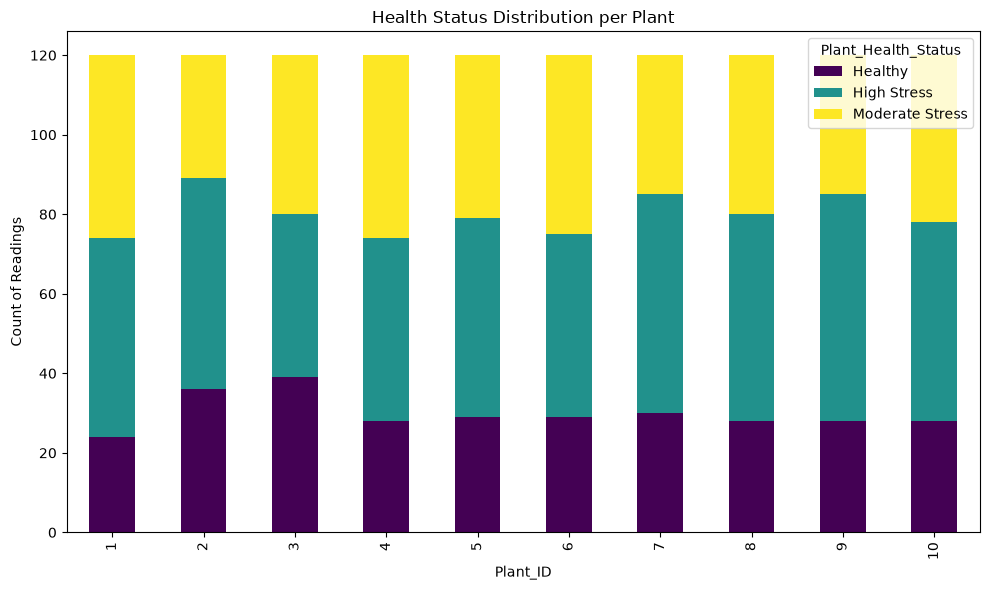

In [6]:
# Stacked/grouped bar chart of health status per plant
ax = ct_counts.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
ax.set_title('Health Status Distribution per Plant')
ax.set_xlabel('Plant_ID')
ax.set_ylabel('Count of Readings')
ax.legend(title='Plant_Health_Status')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/M2_plantid_vs_healthstatus.png')
plt.show()

## 5. Apply Categorical Target Encoding

Since the target has 3 classes, we implement **per-class mean target encoding**
(target-frequency / class-probability encoding): for each `Plant_ID`, we compute the proportion
of its rows belonging to each of the 3 health-status classes, and add those as 3 new numeric
columns.

In [7]:
# One-hot the target temporarily just to compute per-plant class proportions
target_dummies = pd.get_dummies(df['Plant_Health_Status'], prefix='target')
temp = pd.concat([df['Plant_ID'], target_dummies], axis=1)
plant_target_means = temp.groupby('Plant_ID').mean()
plant_target_means.columns = [
    f"PlantID_encoded_{c.replace('target_', '')}" for c in plant_target_means.columns
]
print(plant_target_means)

df_encoded = df.merge(plant_target_means, on='Plant_ID', how='left')
df_encoded.drop(columns=['Plant_ID'], inplace=True)
df_encoded.head()

          PlantID_encoded_Healthy  PlantID_encoded_High Stress  \
Plant_ID                                                         
1                        0.200000                     0.416667   
2                        0.300000                     0.441667   
3                        0.325000                     0.341667   
4                        0.233333                     0.383333   
5                        0.241667                     0.416667   
6                        0.241667                     0.383333   
7                        0.250000                     0.458333   
8                        0.233333                     0.433333   
9                        0.233333                     0.475000   
10                       0.233333                     0.416667   

          PlantID_encoded_Moderate Stress  
Plant_ID                                   
1                                0.383333  
2                                0.258333  
3                              

,Soil_Moisture,Ambient_Temperature,Soil_Temperature,Humidity,Light_Intensity,Soil_pH,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Chlorophyll_Content,Electrochemical_Signal,Plant_Health_Status,PlantID_encoded_Healthy,PlantID_encoded_High Stress,PlantID_encoded_Moderate Stress
0,27.521109,22.240245,21.900435,55.291904,556.172805,5.581955,10.003650,45.806852,39.076199,35.703006,0.941402,High Stress,0.2,0.416667,0.383333
1,14.835566,21.706763,18.680892,63.949181,596.136721,7.135705,30.712562,25.394393,17.944826,27.993296,0.164899,High Stress,0.2,0.416667,0.383333
2,17.086362,21.180946,15.392939,67.837956,591.124627,5.656852,29.337002,27.573892,35.706530,43.646308,1.081728,High Stress,0.2,0.416667,0.383333
3,15.336156,22.593302,22.778394,58.190811,241.412476,5.584523,16.966621,26.180705,26.257746,37.838095,1.186088,High Stress,0.2,0.416667,0.383333
4,39.822216,28.929001,18.100937,63.772036,444.493830,5.919707,10.944961,37.898907,37.654483,48.265812,1.609805,High Stress,0.2,0.416667,0.383333


**What this produced:** each row now has 3 new columns
(`PlantID_encoded_Healthy`, `PlantID_encoded_Moderate Stress`, `PlantID_encoded_High Stress`)
representing how strongly its originating plant is historically associated with each
health-status class. These 3 columns replace the single `Plant_ID` column, giving the model a
dense numeric representation of plant identity instead of a raw ID or 10 sparse one-hot columns.

**Leakage risk:** because the encoding is computed using the *full* dataset — including each
row's own label — a row's encoded features are partly derived from its own target value. This is
a form of target leakage: the encoding could make the model appear more accurate than it would
be on truly unseen data. The standard fix is **K-fold target encoding** (or leave-one-out target
encoding), where each row's encoding is computed only from the *other* folds/rows, never from
itself. For this coursework notebook we keep the simpler whole-dataset version, since it is
easier to explain and reason about in the viva, but this leakage caveat should be noted whenever
the encoded output is used for model evaluation.

## 6. Encode Target Variable for Downstream Use

We also map the target labels to integers so the output file is ready for direct use by modeling notebooks.

In [8]:
target_map = {'Healthy': 0, 'Moderate Stress': 1, 'High Stress': 2}
df_encoded['Plant_Health_Status'] = df_encoded['Plant_Health_Status'].map(target_map)
df_encoded.head()

,Soil_Moisture,Ambient_Temperature,Soil_Temperature,Humidity,Light_Intensity,Soil_pH,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Chlorophyll_Content,Electrochemical_Signal,Plant_Health_Status,PlantID_encoded_Healthy,PlantID_encoded_High Stress,PlantID_encoded_Moderate Stress
0,27.521109,22.240245,21.900435,55.291904,556.172805,5.581955,10.003650,45.806852,39.076199,35.703006,0.941402,2,0.2,0.416667,0.383333
1,14.835566,21.706763,18.680892,63.949181,596.136721,7.135705,30.712562,25.394393,17.944826,27.993296,0.164899,2,0.2,0.416667,0.383333
2,17.086362,21.180946,15.392939,67.837956,591.124627,5.656852,29.337002,27.573892,35.706530,43.646308,1.081728,2,0.2,0.416667,0.383333
3,15.336156,22.593302,22.778394,58.190811,241.412476,5.584523,16.966621,26.180705,26.257746,37.838095,1.186088,2,0.2,0.416667,0.383333
4,39.822216,28.929001,18.100937,63.772036,444.493830,5.919707,10.944961,37.898907,37.654483,48.265812,1.609805,2,0.2,0.416667,0.383333


## 7. EDA Visualization

A heatmap comparing the 3 `PlantID_encoded_*` columns across plants, showing at a glance which
plants are most strongly associated with each health-status class.

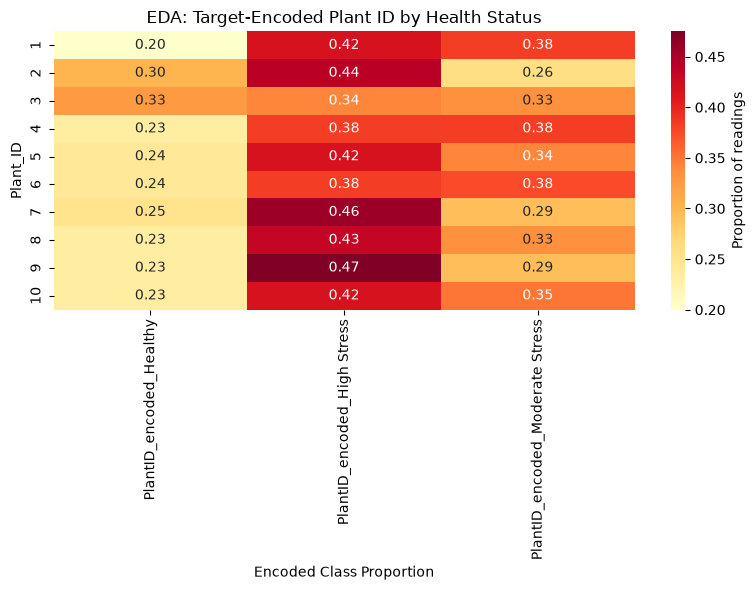

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(plant_target_means, annot=True, fmt='.2f', cmap='YlOrRd', cbar_kws={'label': 'Proportion of readings'})
plt.title('EDA: Target-Encoded Plant ID by Health Status')
plt.xlabel('Encoded Class Proportion')
plt.ylabel('Plant_ID')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/M2_EDA_target_encoding.png')
plt.show()

## 8. Save Output

This output is independent — it does not depend on any other member's file, and no other member's notebook should read from it either.

In [10]:
df_encoded.to_csv('../results/outputs/step_M2_categorical_target_encoded.csv', index=False)
print("Saved:", df_encoded.shape)

Saved: (1200, 15)
